In [1]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

c:\Users\oskar\OneDrive\UNI\AP1\GitHub\AP1-Gruppe-143\Tools.py:240: SyntaxWarning: invalid escape sequence '\h'
  print(f"Da $z = \\left|\\frac{{\hat x-y}}{{\Delta x}}\\right| = \\left|\\frac{{ {Bestwert:.2f} {Einheit} - {Literaturwert:.2f} {Einheit}}}{{{Standardunsicherheit:.2f} {Einheit} }} \\right| = {z:.2f} > 2$, weicht unser Ergebnis Signifikant vom Literaturwert ab.")
c:\Users\oskar\OneDrive\UNI\AP1\GitHub\AP1-Gruppe-143\Tools.py:240: SyntaxWarning: invalid escape sequence '\D'
  print(f"Da $z = \\left|\\frac{{\hat x-y}}{{\Delta x}}\\right| = \\left|\\frac{{ {Bestwert:.2f} {Einheit} - {Literaturwert:.2f} {Einheit}}}{{{Standardunsicherheit:.2f} {Einheit} }} \\right| = {z:.2f} > 2$, weicht unser Ergebnis Signifikant vom Literaturwert ab.")
c:\Users\oskar\OneDrive\UNI\AP1\GitHub\AP1-Gruppe-143\Tools.py:241: SyntaxWarning: invalid escape sequence '\h'
  else: print(f"Da $z = \\left|\\frac{{\hat x-y}}{{\Delta x}}\\right| = \\left|\\frac{{ {Bestwert:.2f} {Einheit} - {Literaturwert:.2f}

Standardabweichung_Periodendauer1:  0.084
Mittelwert1:  3.601


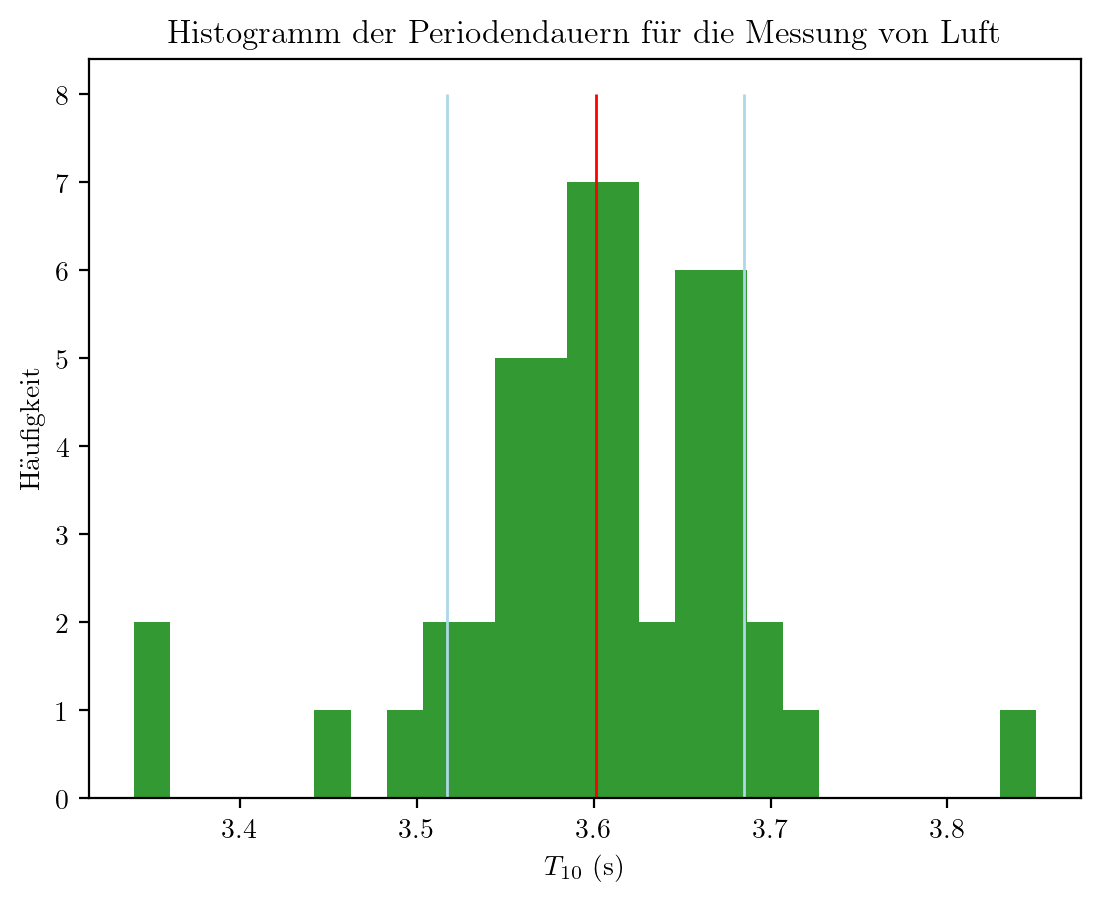

In [2]:
messdaten1 = pd.read_excel("V32.xlsx", sheet_name="MessungT1")
dauer = messdaten1["Zeit [s]"].to_numpy()
# dauer = dauer/10 # Messung für 10 Perioden

Standardabweichung_Periodendauer1 = np.round(np.std(dauer, ddof=1), 3) # Stoppunsicherheit von 10 Perioden
Mittelwert1 = np.round(np.mean(dauer), 3)

print("Standardabweichung_Periodendauer1: ", Standardabweichung_Periodendauer1)
print("Mittelwert1: ", Mittelwert1)

fig, ax = plt.subplots(dpi=200)
ax.hist(dauer, bins=25, alpha=0.8, color='g', label="Messwerte")
ax.vlines(Mittelwert1, 0, 8, color='r', label="Mittelwert", linewidth=1)
ax.vlines([Mittelwert1+Standardabweichung_Periodendauer1, Mittelwert1-Standardabweichung_Periodendauer1],
          0, 8, color='lightblue', label="Mittelwert", linewidth=1)
ax.set_title("Histogramm der Periodendauern für die Messung von Luft")
# ax.set_xticks()
ax.set_xlabel("$T_{10}$ (s)")
ax.set_ylabel("Häufigkeit")
plt.show()

In [3]:
messdaten2 = pd.read_excel("V32.xlsx", sheet_name="Messung2")
perioden = messdaten2["Perioden"].to_numpy()
dauer2 = messdaten2["Dauer (s)"].to_numpy()

periodendauer2 = np.round(dauer2/perioden, 3)
data2 = np.vstack([perioden, periodendauer2])
print(makeLaTexTable(data2, ("Perioden", "Periodendauer"), "Periodendauern über die Anzahl der gemessenen Perioden", tag="PeriodendauernLuft"))

\begin{table}[H]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{l|llllllllll}
\textbf{Perioden}& 1.0	& 2.0	& 5.0	& 10.0	& 20.0	& 50.0	& 100.0	& 200.0	& 500.0	& 1000.0	\\ 
\textbf{Periodendauer}& 0.2	& 0.295	& 0.336	& 0.358	& 0.379	& 0.386	& 0.39	& 0.392	& 0.393	& 0.393	\\ 

\end{tabular}%
}
\caption{Periodendauern über die Anzahl der gemessenen Perioden}
\label{tab:PeriodendauernLuft}
\end{table}


In [4]:
# Kombination der Ergebnisse

# Gewichtsfaktoren
w1 = 1/((Standardabweichung_Periodendauer1/perioden)**2)

# gewichtetes arithmetisches Mittel
gewichtetes_mittel = np.sum(w1*periodendauer2)/np.sum(w1)
print("Gewichtetes mittel: ", gewichtetes_mittel)

# Fehler des gewichteten Mittels
fehler_gewichtetes_mittel = np.sqrt(1/np.sum(w1))
print("Fehler des gewichteten Mittels: ", fehler_gewichtetes_mittel)

Gewichtetes mittel:  0.3929243225405401
Fehler des gewichteten Mittels:  7.358716618243092e-05


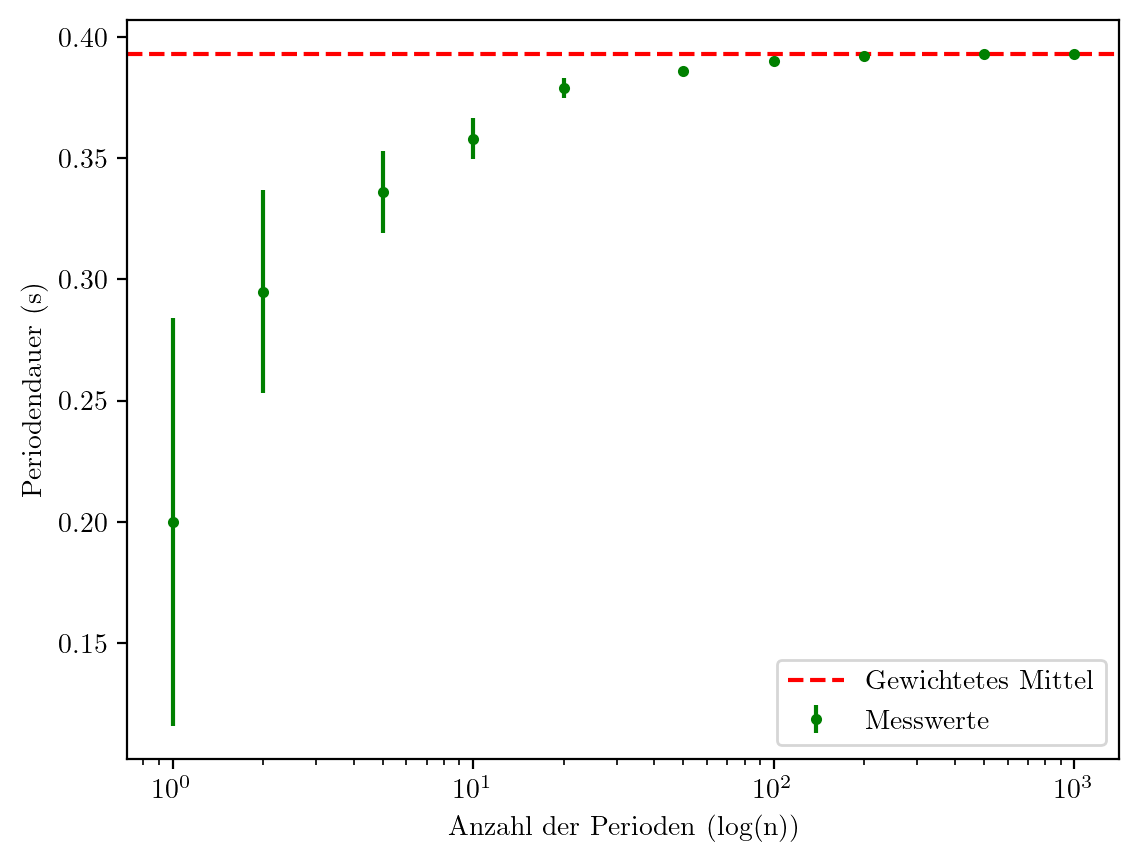

In [5]:
# Diagramm T (linear) gegen n (logarithmisch), Illustration von gewichtetes_Mittel

fehler = 1 # Matti

fig, ax = plt.subplots(dpi=200)
ax.errorbar(perioden, periodendauer2, yerr=Standardabweichung_Periodendauer1/(perioden), fmt='.', label='Messwerte', color='g')
ax.axhline(y=gewichtetes_mittel, color='r', linestyle='--', label='Gewichtetes Mittel')
ax.set_xscale('log')
ax.set_yscale('linear')
ax.set_xlabel('Anzahl der Perioden (log(n))')
ax.set_ylabel('Periodendauer (s)')
ax.legend(loc='lower right')
plt.show()

In [ ]:
# Berechnung des Adiabatenexponenten
m = 5.67e-3
g = 9.808
V = 2220e-6
d = 13.8e-3
pL = 99050

A = np.pi * (d/2)**2
p = pL + (4*m*g)/(np.pi*d**2)
kappa = (4 * np.pi**2 * m * V) / (A**2 * p * gewichtetes_mittel**2) # manuelle Berechnung

# Gausfunktion zur Fehlerfortpflanzung
sm, sg, sV, sd, spL = sp.symbols('m g V d \\rho_L')
# kappa_f = (4 * np.pi**2 * sm * sV) / ((np.pi * (sd/2)**2)**2 * (pL + (4*m*g)/(np.pi*d**2)) * gewichtetes_mittel**2)
kappa_f = ((64 * sm * sV)/(sd**4 * (pL + (4*sm*sg)/(np.pi*sd**2)) * gewichtetes_mittel**2))

k = (gauss_error_values(
    kappa_f,
    [sm, sg, sV, sd, spL],
    [m, g, V, d, pL],
    [0.006e-3, 0.001, 10e-6, 0.02e-3, 20],
    returnLaTex=True
))

print(k)
kappa = k[0]
kappafehler = k[1]

print("Adiabatenexponent: ", np.round(kappa, 3))
print("Literaturwert: ", 1.402)

Term von m: 2,327461129e-06
Term von g: 3,044437784e-13
Term von V: 4,24907536e-05
Term von d: 7,011267602e-05
Term von \rho_L: 0

1. Wert:
1,45

2. Fehler:
0,01

3. LaTeX-Formel:
\begin{equation*}\Delta f = \sqrt{\left(\frac{\partial f}{\partial m}\,\Delta m\right)^2+\left(\frac{\partial f}{\partial g}\,\Delta g\right)^2+\left(\frac{\partial f}{\partial V}\,\Delta V\right)^2+\left(\frac{\partial f}{\partial d}\,\Delta d\right)^2+\left(\frac{\partial f}{\partial \rho_{L}}\,\Delta \rho_{L}\right)^2}} = \sqrt{\left(\frac{414.54 V}{d^{4} \left(99050 + \frac{1.27 g m}{d^{2}}\right)} - \frac{527.8 V g m}{d^{6} \left(99050 + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta m\right)^2+\left(- \frac{527.8 V m^{2}}{d^{6} \left(99050 + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta g\right)^2+\left(\frac{414.54 m}{d^{4} \left(99050 + \frac{1.27 g m}{d^{2}}\right)}\,\Delta V\right)^2+\left(- \frac{1658.14 V m}{d^{5} \left(99050 + \frac{1.27 g m}{d^{2}}\right)} + \frac{1055.61 V g m^{2}}{d^{7} \left(99050 +

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
C:\Users\oskar\AppData\Local\Temp\ipykernel_30584\2200244025.py:9: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma_f$')


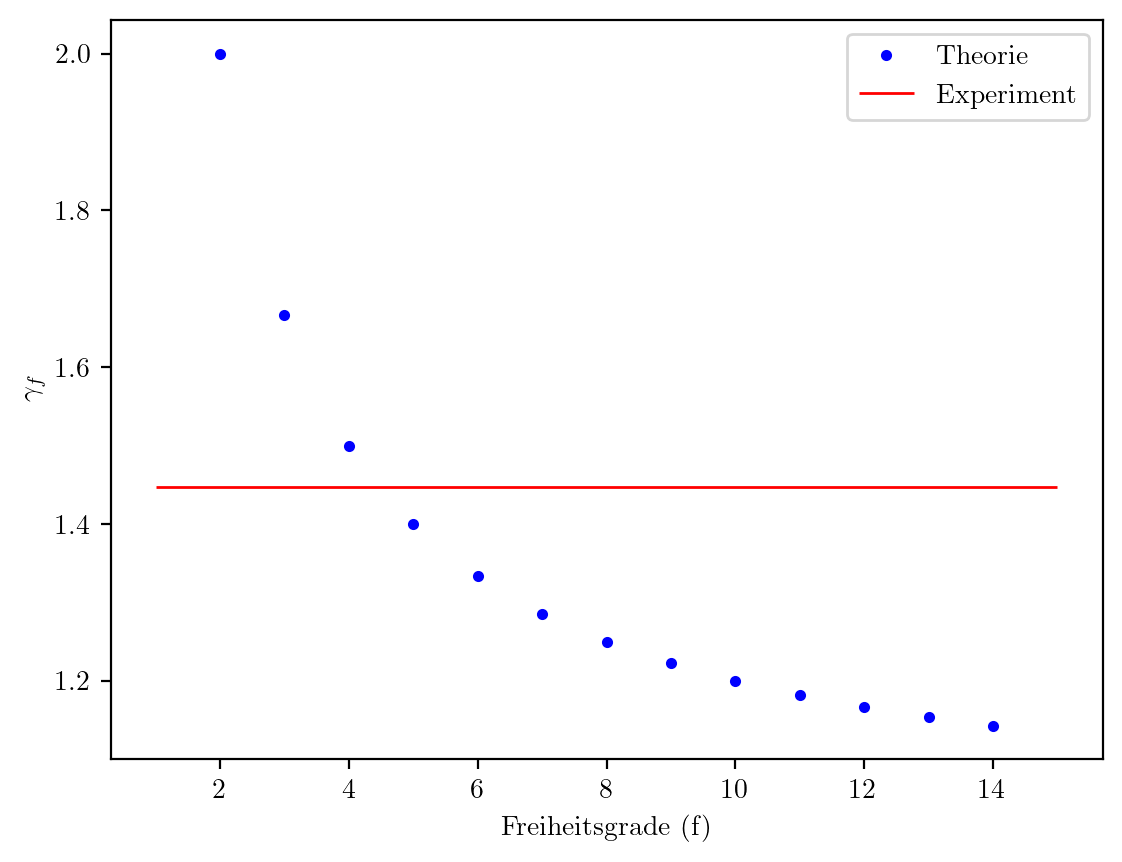

In [7]:
# gamma der Freiheitsgrade
f = np.arange(2, 15)
gammaf = (f+2)/f

fig, ax = plt.subplots(dpi=200)
ax.plot(f, gammaf, '.', label='Theorie', color='b', linewidth=1)
ax.hlines(y=kappa, xmin=1, xmax=15, color='r', linestyle='-', label='Experiment', linewidth=1)
ax.set_xlabel('Freiheitsgrade (f)')
ax.set_ylabel('$\gamma_f$')
ax.legend()
plt.show()

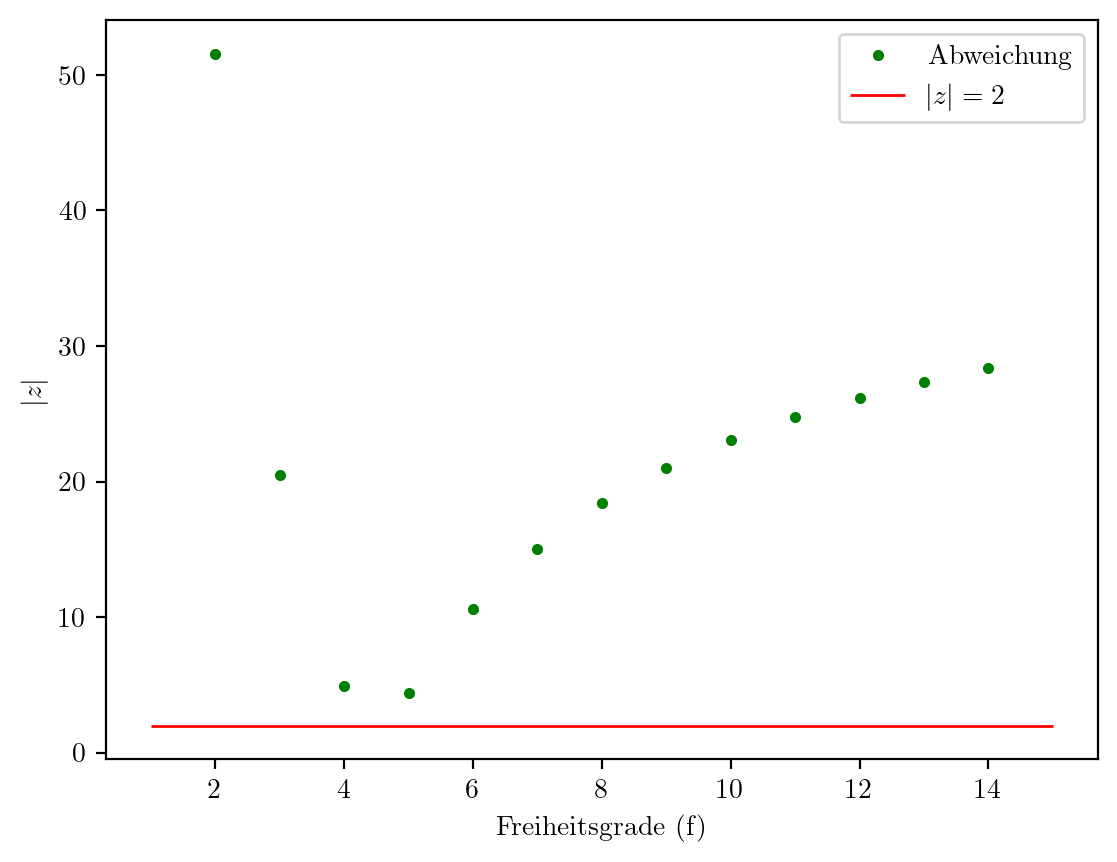

In [8]:
# Diagramm |z| mit z = 2
z = (abs(kappa - gammaf))/kappafehler

fig, ax = plt.subplots(dpi=200)
ax.plot(f, z, '.', label='Abweichung', color='g', linewidth=1)
ax.hlines(y=2, xmin=1, xmax=15, color='r', linestyle='-', label='$|z|=2$', linewidth=1)
ax.set_xlabel('Freiheitsgrade (f)')
ax.set_ylabel('$|z|$')
ax.legend()
plt.show()

In [9]:
p = pL + (4*m*g)/(np.pi*d**2)
kappa = (4 * np.pi**2 * m * V) / (A**2 * p * gewichtetes_mittel**2) # manuelle Berechnung

# Gausfunktion zur Fehlerfortpflanzung
sm, sg, sV, sd, spL = sp.symbols('m g V d \\rho_L')
# kappa_f = (4 * np.pi**2 * sm * sV) / ((np.pi * (sd/2)**2)**2 * (pL + (4*m*g)/(np.pi*sd**2)) * gewichtetes_mittel**2)
kappa_f = ((64 * sm * sV)/(sd**4 * (pL + (4*sm*sg)/(np.pi*sd**2)) * gewichtetes_mittel**2))

k = (gauss_error_values(
    kappa_f,
    [sm, sg, sV, sd, spL],
    [m, g, V, d, pL],
    [0.006e-3, 0.001, 10e-6, 0.02e-3, 20],
    returnLaTex=True
))
print(k[0], k[1])
print(k[2])
print(k[3])
kappa = np.round(k[0], 3)
print("Adiabatenexponent: ", kappa)
print("Literaturwert: ", 1.402)

Term von m: 2,327461129e-06
Term von g: 3,044437784e-13
Term von V: 4,24907536e-05
Term von d: 7,011267602e-05
Term von \rho_L: 0

1. Wert:
1,45

2. Fehler:
0,01

3. LaTeX-Formel:
\begin{equation*}\Delta f = \sqrt{\left(\frac{\partial f}{\partial m}\,\Delta m\right)^2+\left(\frac{\partial f}{\partial g}\,\Delta g\right)^2+\left(\frac{\partial f}{\partial V}\,\Delta V\right)^2+\left(\frac{\partial f}{\partial d}\,\Delta d\right)^2+\left(\frac{\partial f}{\partial \rho_{L}}\,\Delta \rho_{L}\right)^2}} = \sqrt{\left(\frac{414.54 V}{d^{4} \left(99050 + \frac{1.27 g m}{d^{2}}\right)} - \frac{527.8 V g m}{d^{6} \left(99050 + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta m\right)^2+\left(- \frac{527.8 V m^{2}}{d^{6} \left(99050 + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta g\right)^2+\left(\frac{414.54 m}{d^{4} \left(99050 + \frac{1.27 g m}{d^{2}}\right)}\,\Delta V\right)^2+\left(- \frac{1658.14 V m}{d^{5} \left(99050 + \frac{1.27 g m}{d^{2}}\right)} + \frac{1055.61 V g m^{2}}{d^{7} \left(99050 +